# PCD_Assignment01
**Digital Image Processing: Downsampling and Upsampling**

Name: **[YOUR NAME]** | Student ID: **[YOUR STUDENT ID]**

Inputs: `malvin.jpeg` and `pemandangan.jpg`, supplied by the student.
“Medium” is interpreted as **Median**.

**Colab instructions:** Select Runtime > Run all. If prompted, upload BOTH image files from the package's `images` folder. Wait until the final cell prints `DONE`. No GPU or Google Drive mounting is needed. This notebook contains locally verified outputs; rerun it in Colab before submission.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import csv, shutil, json, platform, PIL

OUT = Path('results')
for folder in ['processed_inputs','downsampled','upsampled','figures']:
    (OUT/folder).mkdir(parents=True,exist_ok=True)
print('Python:',platform.python_version(),'NumPy:',np.__version__,'Pillow:',PIL.__version__)


Python: 3.13.15 NumPy: 2.1.3 Pillow: 11.3.0


## 1. Load the two photographs
If the images are not already in `images/` or the current folder, Colab opens an upload button. Select **both** files. Each image is EXIF-oriented and converted to RGB. We keep the original resolution; to support 2× and 4× block pooling, we remove only the last rows/columns needed to make dimensions divisible by 4. There is no preliminary resize or stretching. All quality metrics use this processed input as the reference.


malvin.jpeg: 1200 x 1600 -> 1200 x 1600 (width x height)
pemandangan.jpg: 474 x 842 -> 472 x 840 (width x height)


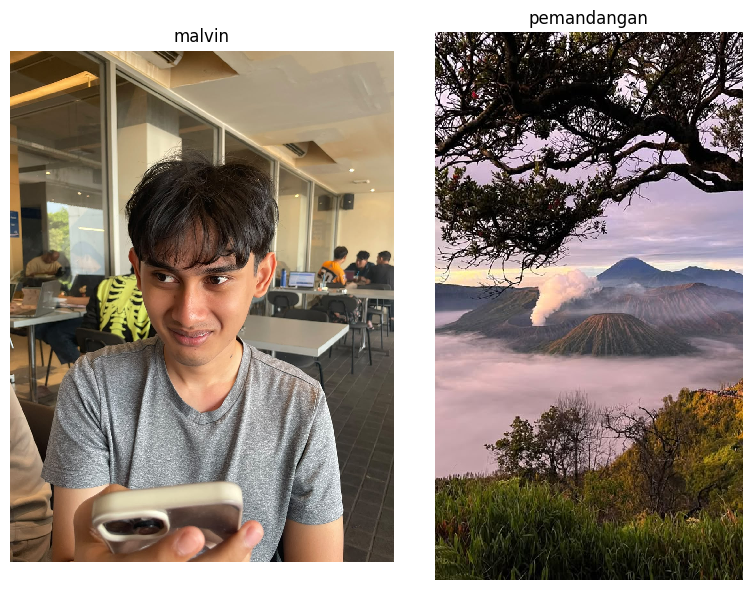

In [3]:
names = ['malvin.jpeg','pemandangan.jpg']
def locate(name):
    return next((p for p in [Path('images')/name, Path(name)] if p.is_file()),None)
missing = [name for name in names if locate(name) is None]
if missing:
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError('Place both input files in images/ before running locally.')
    print('Upload BOTH files:', ', '.join(names))
    files.upload()
missing = [name for name in names if locate(name) is None]
if missing:
    raise FileNotFoundError('Missing files: '+', '.join(missing)+'. Check filenames and run this cell again.')
images = {}
for name in names:
    arr = np.asarray(ImageOps.exif_transpose(Image.open(locate(name))).convert('RGB'))
    h,w = arr.shape[:2]
    arr = arr[:h-h%4,:w-w%4].copy()
    images[Path(name).stem] = arr
    Image.fromarray(arr).save(OUT/'processed_inputs'/f'{Path(name).stem}.png')
    print(f'{name}: {w} x {h} -> {arr.shape[1]} x {arr.shape[0]} (width x height)')
fig,axes=plt.subplots(1,2,figsize=(8,6))
for ax,(name,arr) in zip(axes,images.items()):
    ax.imshow(arr,interpolation='nearest');ax.set_title(name);ax.axis('off')
plt.tight_layout();plt.savefig(OUT/'figures'/'inputs.png',dpi=120);plt.show()


## 2. Downsampling with block pooling
A non-overlapping k × k block becomes one RGB pixel. Max takes its largest value, Average its arithmetic mean, and Median its middle sorted value, independently per channel. For even block sizes, Median averages the two central values. Mean/median results are rounded to 8-bit integers.

Example for one channel: `[0,10;20,250]` gives **Max = 250, Average = 70, Median = 15**.


In [4]:
def downsample(arr, factor, method):
    if not isinstance(factor,int) or factor < 1:
        raise ValueError('factor must be a positive integer')
    h,w,c = arr.shape
    if h%factor or w%factor:
        raise ValueError('Dimensions must be divisible by factor')
    blocks = arr.reshape(h//factor,factor,w//factor,factor,c)
    reducer = {'Max':np.max,'Average':np.mean,'Median':np.median}[method]
    return np.clip(np.rint(reducer(blocks,axis=(1,3))),0,255).astype(np.uint8)

sample = np.repeat(np.array([[0,10],[20,250]],dtype=np.uint8)[...,None],3,axis=2)
assert [int(downsample(sample,2,m)[0,0,0]) for m in ['Max','Average','Median']] == [250,70,15]
print('Downsampling example passed.')


Downsampling example passed.


## 3. Upsampling and evaluation
Nearest Neighbor (NN) selects the closest source sample. Bilinear uses linear interpolation; Bicubic uses cubic interpolation over a wider neighborhood. We use Pillow's implementations and explicitly select the filter.

MSE = mean((reference - reconstruction)²). PSNR = 10 log10(255² / MSE).
Lower MSE / higher PSNR means closer pixel agreement. These metrics evaluate the **complete down-up pipeline**, not downsampling alone. They do not directly measure perceived sharpness. Both arrays are compared at the same original processed dimensions.

Reference: [Pillow filters](https://pillow.readthedocs.io/en/stable/handbook/concepts.html#filters).


In [7]:
FILTERS = {'NN':Image.Resampling.NEAREST,
           'Bilinear':Image.Resampling.BILINEAR,
           'Bicubic':Image.Resampling.BICUBIC}
def upsample(arr, size, method):
    return np.asarray(Image.fromarray(arr).resize(size,resample=FILTERS[method]))
def quality(reference,result):
    mse=float(np.mean((reference.astype(np.float64)-result.astype(np.float64))**2))
    psnr=float('inf') if mse == 0 else float(10*np.log10(255**2/mse))
    return mse,psnr


## 4. Execute 36 pipelines
Two photographs × two reduction factors (2 and 4) × three downsampling methods × three upsampling methods.

The original processed resolutions are restored after downsampling. Output PNGs are lossless, so JPEG re-encoding does not affect the comparison. Full-image figures are for orientation; inspect the detailed crops in the next section for interpolation differences.


In [8]:
records=[]
for name,original in images.items():
    h,w=original.shape[:2]
    for factor in [2,4]:
        for down in ['Max','Average','Median']:
            low=downsample(original,factor,down)
            Image.fromarray(low).save(OUT/'downsampled'/f'{name}_{factor}x_{down}.png')
            for up in FILTERS:
                result=upsample(low,(w,h),up)
                assert result.shape == original.shape
                mse,psnr=quality(original,result)
                records.append(dict(image=name,factor=factor,down=down,up=up,mse=mse,psnr_db=psnr))
                Image.fromarray(result).save(OUT/'upsampled'/f'{name}_{factor}x_{down}_{up}.png')
with (OUT/'metrics.csv').open('w',newline='') as f:
    writer=csv.DictWriter(f,fieldnames=records[0].keys())
    writer.writeheader();writer.writerows(records)
assert len(records)==36
for name in images:
    print('\n'+name)
    for factor in [2,4]:
        for r in [r for r in records if r['image']==name and r['factor']==factor]:
            print(f"{factor}x | {r['down']:7} + {r['up']:8} | MSE {r['mse']:8.2f} | PSNR {r['psnr_db']:6.2f} dB")



malvin
2x | Max     + NN       | MSE    93.60 | PSNR  28.42 dB
2x | Max     + Bilinear | MSE    81.26 | PSNR  29.03 dB
2x | Max     + Bicubic  | MSE    74.84 | PSNR  29.39 dB
2x | Average + NN       | MSE    36.21 | PSNR  32.54 dB
2x | Average + Bilinear | MSE    30.27 | PSNR  33.32 dB
2x | Average + Bicubic  | MSE    21.62 | PSNR  34.78 dB
2x | Median  + NN       | MSE    37.20 | PSNR  32.43 dB
2x | Median  + Bilinear | MSE    30.09 | PSNR  33.35 dB
2x | Median  + Bicubic  | MSE    21.88 | PSNR  34.73 dB
4x | Max     + NN       | MSE   422.97 | PSNR  21.87 dB
4x | Max     + Bilinear | MSE   372.97 | PSNR  22.41 dB
4x | Max     + Bicubic  | MSE   374.81 | PSNR  22.39 dB
4x | Average + NN       | MSE   106.97 | PSNR  27.84 dB
4x | Average + Bilinear | MSE    85.36 | PSNR  28.82 dB
4x | Average + Bicubic  | MSE    73.51 | PSNR  29.47 dB
4x | Median  + NN       | MSE   113.31 | PSNR  27.59 dB
4x | Median  + Bilinear | MSE    83.64 | PSNR  28.91 dB
4x | Median  + Bicubic  | MSE    74.71 |

## 5. Visual comparison at 4× reduction
The first figure for each photograph compares the original with three low-resolution outputs. Reduced images occupy the same display area to make their content comparable, but their actual pixel dimensions are smaller.

The second figure compares a **160 × 160 source-coordinate crop** of the original with reconstructed crops. Rows vary downsampling; columns vary upsampling. All panels use `interpolation='nearest'` in Matplotlib so the display adds no smooth interpolation. The portrait crop covers fine image texture; the landscape crop covers branches against sky. No claims about people's appearance are involved.


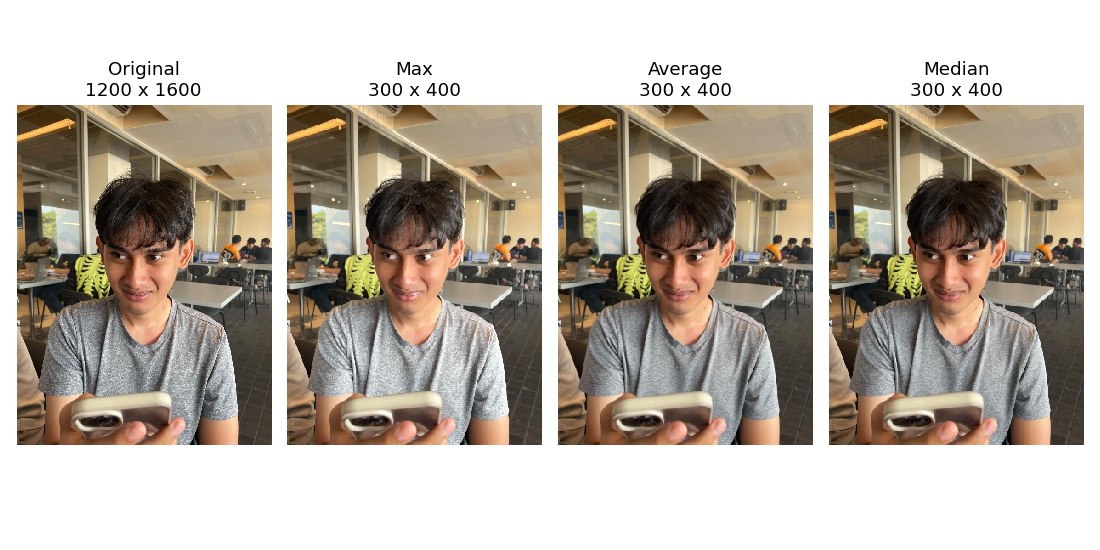

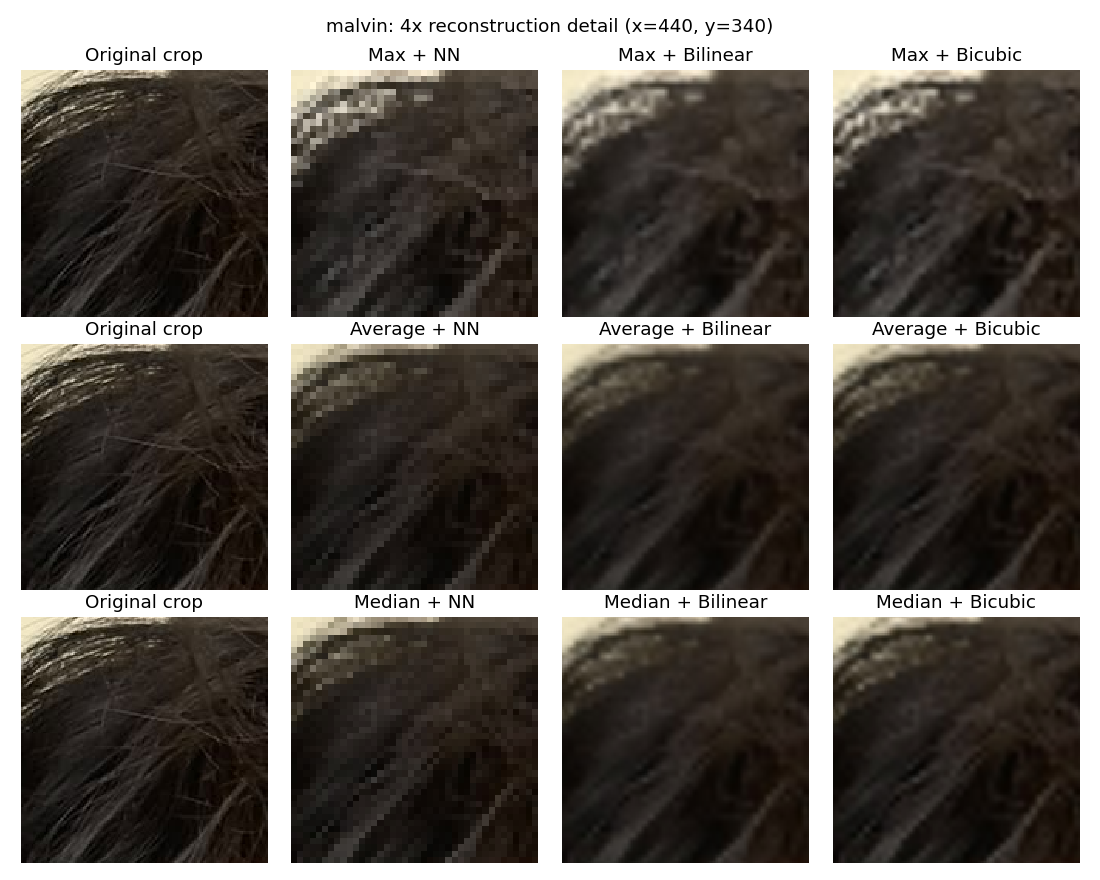

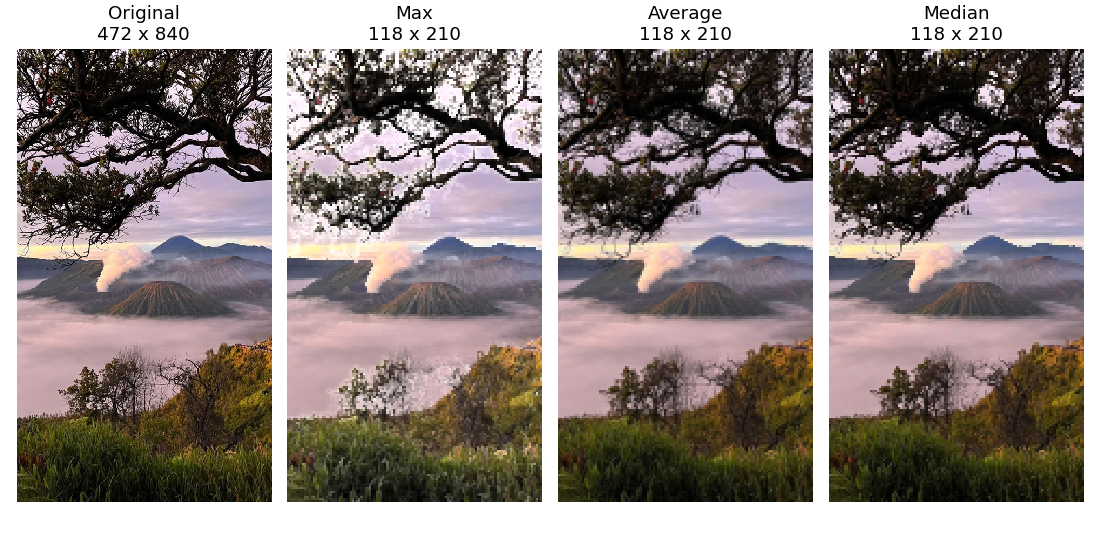

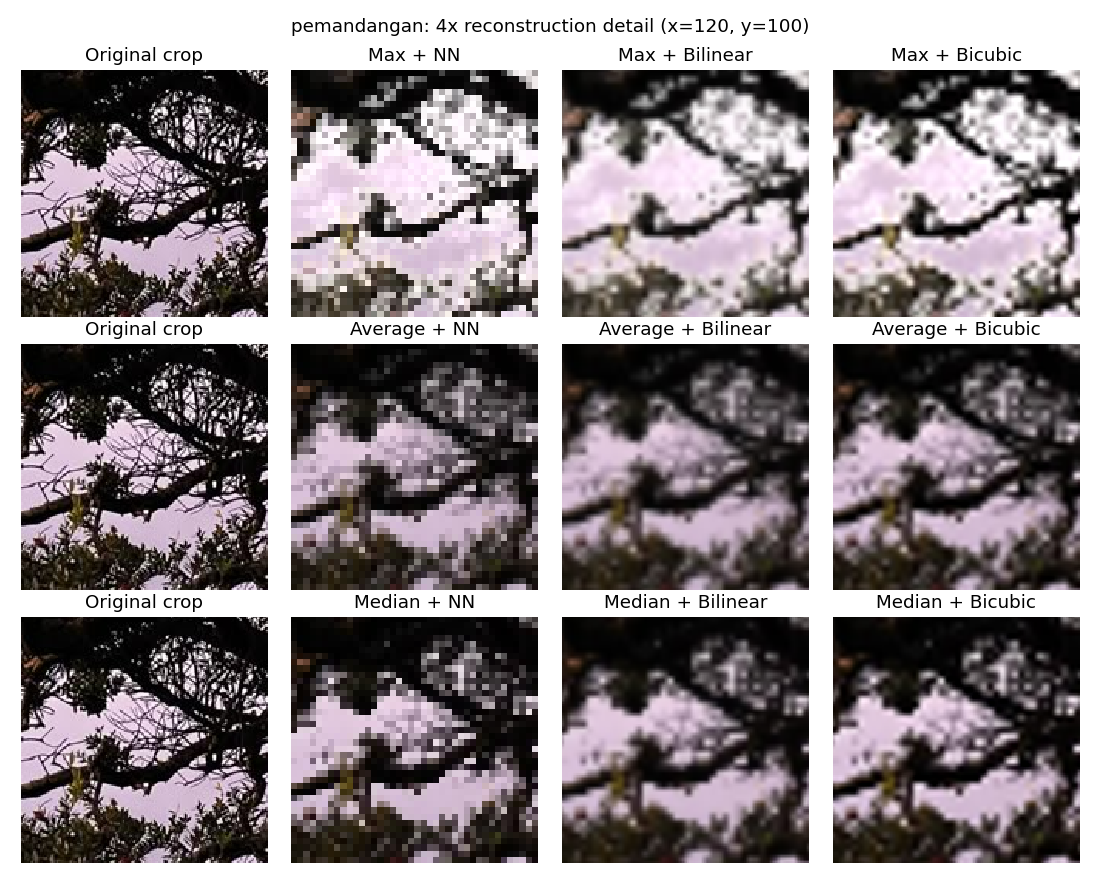

In [ ]:
crop_origins={'malvin':(440,340),'pemandangan':(120,100)}
for name,original in images.items():
    h,w=original.shape[:2]
    fig,axes=plt.subplots(1,4,figsize=(10,5))
    panels=[('Original',original)]+[(m,downsample(original,4,m)) for m in ['Max','Average','Median']]
    for ax,(label,arr) in zip(axes,panels):
        ax.imshow(arr,interpolation='nearest');ax.set_title(f'{label}\n{arr.shape[1]} x {arr.shape[0]}');ax.axis('off')
    plt.tight_layout();plt.savefig(OUT/'figures'/f'{name}_downsampling.png',dpi=130);plt.show()
    x,y=crop_origins[name];side=160
    fig,axes=plt.subplots(3,4,figsize=(10,8))
    for row,down in enumerate(['Max','Average','Median']):
        axes[row,0].imshow(original[y:y+side,x:x+side],interpolation='nearest')
        axes[row,0].set_title('Original crop')
        low=downsample(original,4,down)
        for col,up in enumerate(FILTERS,1):
            result=upsample(low,(w,h),up)
            axes[row,col].imshow(result[y:y+side,x:x+side],interpolation='nearest')
            axes[row,col].set_title(f'{down} + {up}')
        for ax in axes[row]:ax.axis('off')
    fig.suptitle(f'{name}: 4x reconstruction detail (x={x}, y={y})')
    plt.tight_layout();plt.savefig(OUT/'figures'/f'{name}_detail.png',dpi=130);plt.show()


## 6. Summary and analysis
Compare the printed winners with `Report_Analysis.pdf`, which analyzes these two supplied photographs. Max tends to emphasize brighter samples, Average blends local variation, and Median may remove minority details within a block. NN shows repeated blocks; Bilinear smooths transitions; Bicubic often retains stronger transitions. No interpolation method can recover detail that was discarded during reduction.

A noisy-image test is not included here; therefore this experiment does not establish a denoising ranking. The two source photographs have different native resolutions, so their PSNR values are not a controlled comparison of scene difficulty.


In [9]:
for name in images:
    for factor in [2,4]:
        subset=[r for r in records if r['image']==name and r['factor']==factor]
        best=max(subset,key=lambda r:r['psnr_db'])
        print(f"{name}, {factor}x: best = {best['down']} + {best['up']}, {best['psnr_db']:.2f} dB")
archive=shutil.make_archive('PCD_Assignment01_results','zip',OUT)
print('DONE: all 36 pipelines completed. Figures and metrics are in results/.')
print('Save this executed notebook using File > Download > Download .ipynb.')


malvin, 2x: best = Average + Bicubic, 34.78 dB
malvin, 4x: best = Average + Bicubic, 29.47 dB
pemandangan, 2x: best = Average + Bicubic, 22.84 dB
pemandangan, 4x: best = Average + Bicubic, 19.22 dB
DONE: all 36 pipelines completed. Figures and metrics are in results/.
Save this executed notebook using File > Download > Download .ipynb.


## Optional: download regenerated result images
The submission package already includes the same results. To download your Colab-generated results, change `DOWNLOAD_RESULTS` to `True` and run the cell below. Extract the downloaded ZIP into your local submission folder's `results/` folder if you want to replace the supplied results.


In [10]:
DOWNLOAD_RESULTS = False
if DOWNLOAD_RESULTS:
    from google.colab import files
    files.download(archive)
